### K-Means , DBscan Clustering Workflow

This notebook demonstrates how to prepare data, choose a suitable number of clusters, train a K-Means model, and visualize the resulting groups.

### Step 1: Import the required libraries

Load the tools used for data handling, synthetic-data creation, scaling, clustering, and visualization.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs , make_moons
from sklearn.cluster import KMeans , DBSCAN
import seaborn as sns
from sklearn.preprocessing import StandardScaler

### Step 2: Generate synthetic data

Create a two-feature dataset containing four underlying groups. The true labels are retained only as reference; K-Means itself does not use them.

In [72]:
# Step 1: Generate synthetic data
X, y_true = make_blobs(
    n_samples=300,       # total number of points
    centers=4,           # number of actual clusters (ground truth)
    cluster_std=0.60,    # spread/tightness of each cluster
    random_state=42
)
print("Feature shape:", X.shape)   # (300, 2) -> 300 points, 2 features
print("True labels shape:", y_true.shape)

Feature shape: (300, 2)
True labels shape: (300,)


### Step 3: Create and inspect a DataFrame

Place the feature matrix in a pandas DataFrame with descriptive column names, then preview the first rows.

In [73]:
df = pd.DataFrame(X,columns=['feature1','feature2'])
df.head()

,feature1,feature2
0,-9.113944,6.813616
1,-9.354576,7.092790
2,-2.015671,8.281780
3,-7.010236,-6.220843
4,-10.061202,6.718671


### Step 4: Standardize the features

Scale both features to comparable ranges so that neither one has an unintended influence on distance-based clustering.

In [74]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)
df_scaled = pd.DataFrame(df_scaled, columns=df.columns)

### Step 5: Prepare the elbow-method evaluation

Test candidate cluster counts from 1 to 10 and store their inertia values. Inertia, also called within-cluster sum of squares (WCSS), measures how compact the clusters are.

In [75]:
inertia = []
k_range = range(1,11)

### Step 6: Fit K-Means for each candidate value of K

Train one model for every candidate cluster count and record its inertia for comparison.

In [76]:
for i in k_range:
    kmeans = KMeans(n_clusters=i ,random_state=42)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_) # inertia = WCSS

### Step 7: Inspect the inertia values

Review the collected scores before plotting them. Lower inertia is expected as K increases, so the useful choice is usually where the improvement begins to level off.

In [77]:
inertia

[600.0000000000001,
 310.53817039287077,
 62.887904537290126,
 6.415444329452049,
 5.745211730430972,
 5.084397644041042,
 4.7606152218368845,
 3.9596312987388504,
 3.5913165848620525,
 3.3249546060444803]

### Step 8: Plot the elbow curve

Visualize inertia against the number of clusters. The bend, or elbow, suggests a good balance between compact clusters and model simplicity.

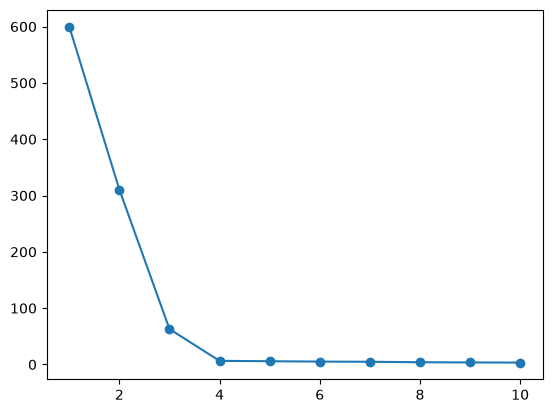

In [78]:
plt.plot(k_range, inertia, marker='o')

### Step 9: Train the final K-Means model

Use the selected value of K (4), assign a cluster label to every observation, and add those labels to the scaled dataset.

In [79]:
kmeans_final = KMeans(n_clusters=4, random_state=42)
cluster_labels = kmeans_final.fit_predict(df_scaled)
df_scaled['clusters'] = cluster_labels
df_scaled.head()

,feature1,feature2,clusters
0,-1.095185,0.640437,3
1,-1.141315,0.685549,3
2,0.265578,0.877679,0
3,-0.691897,-1.465810,1
4,-1.276778,0.625095,3


### Step 10: Visualize the final clusters

Create a scatter plot where color represents the cluster assigned by the final model.

<Axes: xlabel='feature1', ylabel='feature2'>

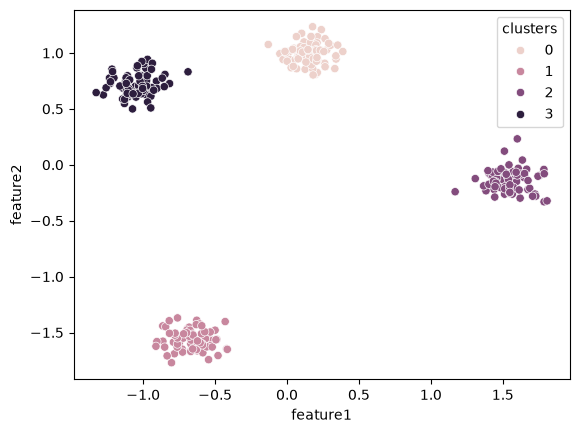

In [80]:
sns.scatterplot(data=df_scaled ,x='feature1' , y='feature2' , hue='clusters')

In [81]:
X, y_true = make_moons(n_samples=500, noise=0.05, random_state=42)

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

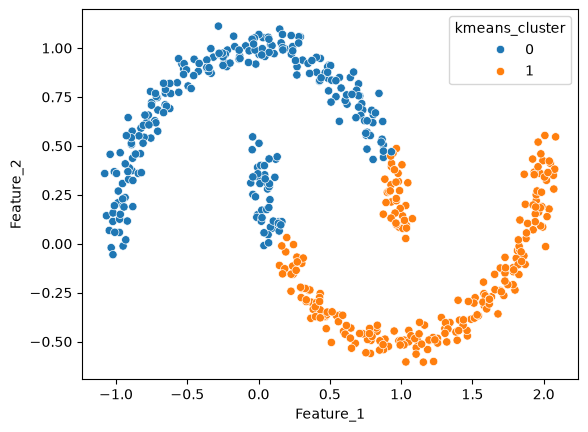

In [82]:
df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])

     

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
     

kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)
     

df['kmeans_cluster'] = kmeans_labels

     

sns.scatterplot(x=df['Feature_1'], y=df['Feature_2'], hue=df['kmeans_cluster'], palette='tab10')

In [83]:

dbscan = DBSCAN(eps=0.3, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

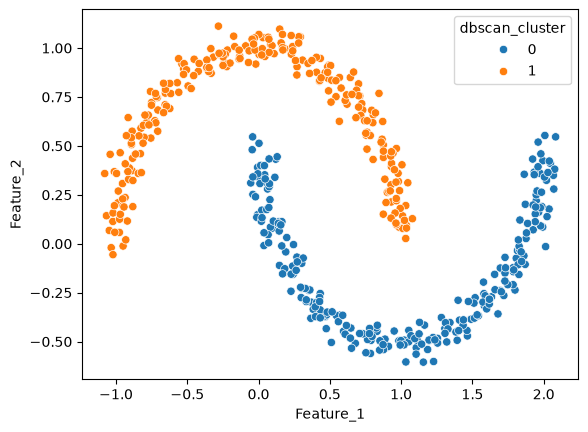

In [ ]:
df['dbscan_cluster'] = dbscan_labels

sns.scatterplot(x=df['Feature_1'], y=df['Feature_2'], hue=df['dbscan_cluster'], palette='tab10')